# Imports

In [113]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 31,
    "figure.titlesize": 31,
    "axes.titlepad": 20,
})

# Load Evergreen Results

In [114]:
RESULT_FILE_EG = r"C:\Programming\rag_seminar\data-science-seminar\experiments\initial_experiment\queries_evergreen_results.json"

with open(RESULT_FILE_EG, "r", encoding="utf-8") as f:
    data_eg = json.load(f)

print(f"Loaded {len(data_eg)} evergreen queries")

Loaded 60 evergreen queries


# Load Time-Sensitive Results

In [115]:
RESULT_FILE_TS = r"C:\Programming\rag_seminar\data-science-seminar\experiments\ts_explicit_01\queries_time_sensitive_explicit_marked_results.json"

with open(RESULT_FILE_TS, "r", encoding="utf-8") as f:
    data_ts = json.load(f)

print(f"Loaded {len(data_ts)} time-sensitive queries")

Loaded 60 time-sensitive queries


# Extract Publication Dates, Topic, and Query Type
Topic and query type are parsed directly from each query's `id` (e.g. `fm_ts_01` -> topic=`fm`, query_type=`ts`), so this doesn't depend on hardcoding which topic prefixes you used.

In [116]:
ID_PATTERN = re.compile(r"^([a-z]+)_(ts|eg|tm)_(\d+)$")

def extract_rows(data, source_label):
    """Flatten query->results into rows, tagging each with topic + query_type
    parsed from the query id. source_label is used as a fallback query_type
    only if an id doesn't match the expected pattern."""
    rows = []
    for query in data:
        query_id = query.get("id")
        if query_id is None:
            raise KeyError(
                f"Could not find an 'id' or 'query_id' field on a query in "
                f"{source_label}; available keys: {list(query.keys())}"
            )

        match = ID_PATTERN.match(query_id)
        if match:
            topic_prefix, query_type, _ = match.groups()
        else:
            topic_prefix, query_type = "unknown", source_label

        for result in query["results"]:
            rows.append({
                "query_id": query_id,
                "topic": topic_prefix,
                "query_type": query_type,
                "published_date": result["published_date"],
            })
    return rows

rows = extract_rows(data_eg, "eg") + extract_rows(data_ts, "ts")
df = pd.DataFrame(rows)

print(f"Loaded {len(df)} retrieved documents total")
print(df["query_type"].value_counts())
print(df["topic"].value_counts())
df.head()

Loaded 1200 retrieved documents total
query_type
eg    600
ts    600
Name: count, dtype: int64
topic
unknown    600
fm         200
ip         200
uf         200
Name: count, dtype: int64


,query_id,topic,query_type,published_date
0,fm_eg_01,fm,eg,2017-11-06
1,fm_eg_01,fm,eg,2017-11-03
2,fm_eg_01,fm,eg,2017-11-03
3,fm_eg_01,fm,eg,2020-01-04
4,fm_eg_01,fm,eg,2019-01-04


# Calculate age relative to 2025-01-01

In [117]:
REFERENCE_DATE = pd.Timestamp("2025-01-01")

df["published_date"] = pd.to_datetime(df["published_date"])

df["age_days"] = (
    REFERENCE_DATE - df["published_date"]
).dt.days

## Mean and median age by query type


In [118]:
age_summary = df.groupby("query_type")["age_days"].agg(["mean", "median", "std", "count"])
print(age_summary)

                   mean  median         std  count
query_type                                        
eg          1231.951667  1079.0  872.774791    600
ts          1366.355000  1156.0  929.229982    600


## Histogram: age distribution, evergreen vs. time-sensitive (Deprecated)
Overlaid histograms of `age_days`, faceted by topic. Bin edges are shared across both query types (and across topics) so the shapes are directly comparable.

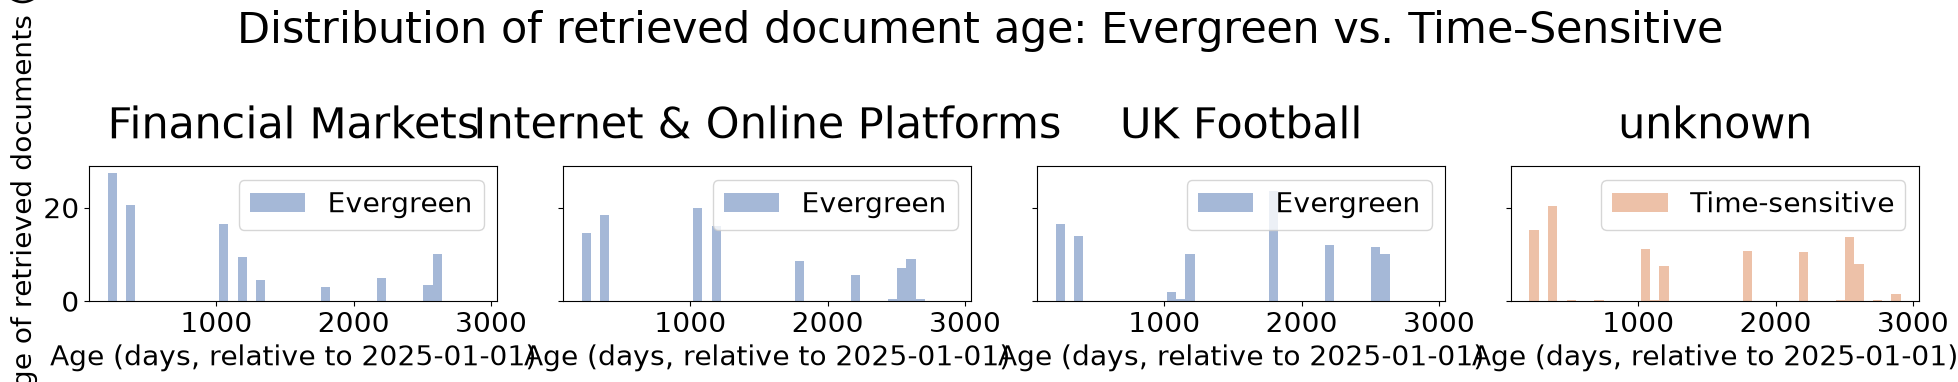

In [119]:
topics = sorted(df["topic"].unique())
n_topics = len(topics)


TOPIC_LABELS = {
    "fm": "Financial Markets",
    "ip": "Internet & Online Platforms",
    "uf": "UK Football",
}

fig, axes = plt.subplots(1, n_topics, figsize=(5 * n_topics, 4), sharey=True)
if n_topics == 1:
    axes = [axes]

n_bins = 40
bin_edges = np.linspace(df["age_days"].min(), df["age_days"].max(), n_bins + 1)

colors = {"eg": "#4C72B0", "ts": "#DD8452", "tm": "#DD8452"}
labels = {"eg": "Evergreen", "ts": "Time-sensitive", "tm": "Time-sensitive"}

for ax, topic in zip(axes, topics):
    subset = df[df["topic"] == topic]
    for query_type in ["eg", "ts", "tm"]:
        values = subset.loc[subset["query_type"] == query_type, "age_days"]
        if len(values) == 0:
            continue
        weights = np.full(len(values), 100 / len(values))
        ax.hist(
            values,
            bins=bin_edges,
            weights=weights,
            alpha=0.5,
            label=labels[query_type],
            color=colors[query_type],
        )
    ax.set_title(TOPIC_LABELS.get(topic, topic))
    ax.set_xlabel("Age (days, relative to 2025-01-01)")
    ax.legend()

axes[0].set_ylabel("Percentage of retrieved documents (%)")
fig.suptitle("Distribution of retrieved document age: Evergreen vs. Time-Sensitive")
plt.tight_layout()
plt.show()

## Butterfly chart: publication date distribution, Evergreen vs. Time-sensitive (all topics combined)
Retrieved documents are binned by publication date. Time-sensitive counts are plotted above the x-axis, evergreen counts below it, combining all three topics.

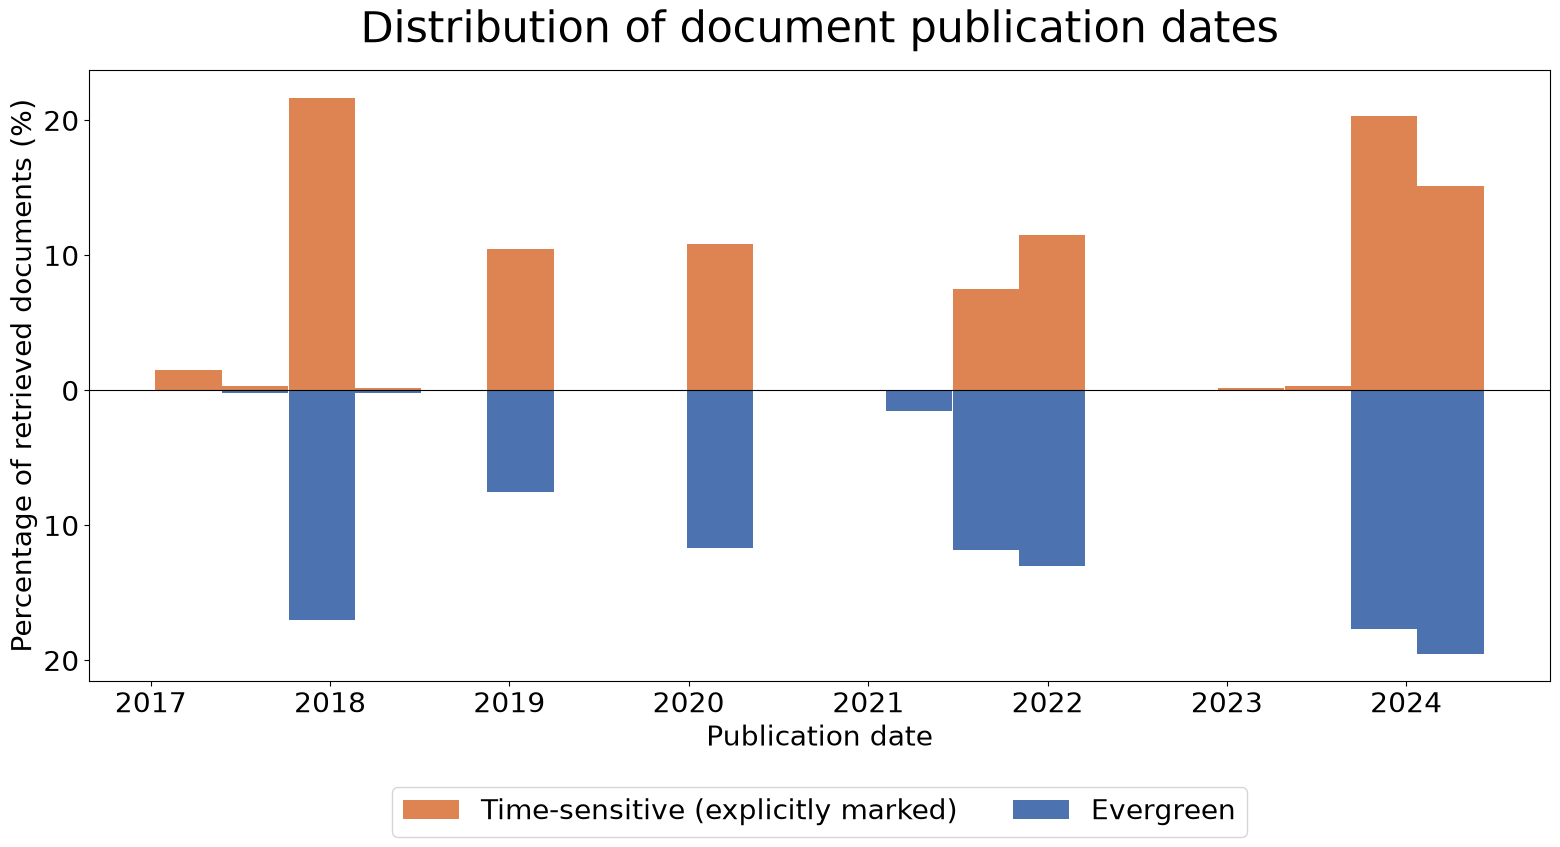

In [122]:
n_bins = 20

dates_numeric = df["published_date"].values.astype("datetime64[D]").astype(int)
bin_edges = np.linspace(dates_numeric.min(), dates_numeric.max(), n_bins + 1)
bin_centers = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype("datetime64[D]")
bin_width = bin_edges[1] - bin_edges[0]

eg_mask = df["query_type"] == "eg"
ts_mask = df["query_type"].isin(["ts", "tm"])

eg_counts, _ = np.histogram(dates_numeric[eg_mask], bins=bin_edges)
ts_counts, _ = np.histogram(dates_numeric[ts_mask], bins=bin_edges)

eg_pct = eg_counts / eg_counts.sum() * 100
ts_pct = ts_counts / ts_counts.sum() * 100

fig, ax = plt.subplots(figsize=(16, 9))
ax.bar(bin_centers, ts_pct, width=bin_width, color="#DD8452", label="Time-sensitive (explicitly marked)")
ax.bar(bin_centers, -eg_pct, width=bin_width, color="#4C72B0", label="Evergreen")
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(lambda value, pos: f"{abs(value):g}")

ax.set_xlabel("Publication date")
ax.set_ylabel("Percentage of retrieved documents (%)")
ax.set_title("Distribution of document publication dates")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

## Overlayed bar chart: publication date distribution, Evergreen vs. Time-sensitive (all topics combined)


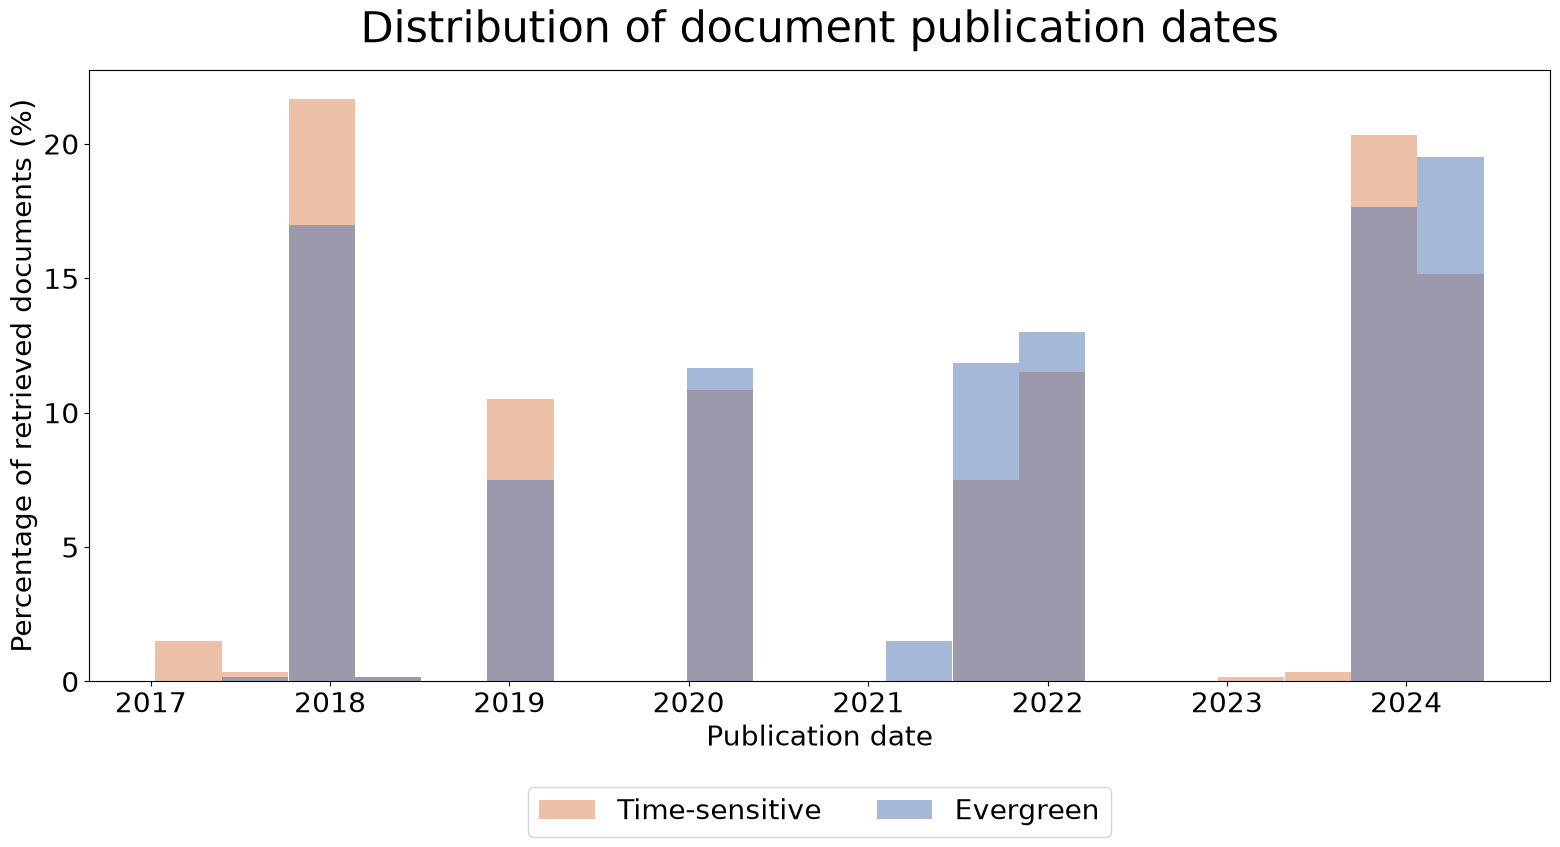

In [121]:
n_bins = 20

dates_numeric = df["published_date"].values.astype("datetime64[D]").astype(int)
bin_edges = np.linspace(dates_numeric.min(), dates_numeric.max(), n_bins + 1)
bin_centers = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype("datetime64[D]")
bin_width = bin_edges[1] - bin_edges[0]

eg_mask = df["query_type"] == "eg"
ts_mask = df["query_type"].isin(["ts", "tm"])

eg_counts, _ = np.histogram(dates_numeric[eg_mask], bins=bin_edges)
ts_counts, _ = np.histogram(dates_numeric[ts_mask], bins=bin_edges)

eg_pct = eg_counts / eg_counts.sum() * 100
ts_pct = ts_counts / ts_counts.sum() * 100

fig, ax = plt.subplots(figsize=(16, 9))
ax.bar(bin_centers, ts_pct, width=bin_width, color="#DD8452", alpha=0.5, label="Time-sensitive")
ax.bar(bin_centers, eg_pct, width=bin_width, color="#4C72B0", alpha=0.5, label="Evergreen")

ax.set_xlabel("Publication date")
ax.set_ylabel("Percentage of retrieved documents (%)")
ax.set_title("Distribution of document publication dates")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()